# 2. Watch a plasma wake in WarpX

This is a small **3D teaching example** of laser wakefield acceleration. 
A short laser pulse interacts with a plasma. 
The laser pushes the plasma electrons aside and they oscillate behind it, creating a wake that can accelerate electrons. 
A short density drop changes the wake and can enable trapping.

We will look at electron density, the accelerating field, and the energy spectrum.

Registered participants can open their AWS session from the link sent in Slack. 
Run the simulation in the GPU terminal environment, then use this notebook
from the `htu` folder to analyze the saved output. The hosted **WarpX GPU**
kernel includes the analysis packages; plotting itself does not need a GPU.


In [1]:
import os
import sys

import matplotlib.pyplot as plt
from openpmd_viewer import OpenPMDTimeSeries
from tutorial_helpers import plot_density_evolution, plot_snapshot

## Run the simulation in a terminal

From `htu/lwfa_warpx/`, activate the hosted GPU environment and run:

```bash
source /opt/venv-gpu/bin/activate
time python run_lwfa_warpx.py > run.log 2>&1
```

The driver reads `lwfa_warpx_input.txt` and writes to `diags/`. It does not
create a fresh directory on each run. Before a repeat, preserve the completed
run's `diags` folder and `run.log` under new, unused names. Record the elapsed
(`real`) time, inspect the log for successful completion, and measure output
size with `du -sh diags`.

In a second terminal, use `nvidia-smi` to inspect GPU activity while the run
is active. On other systems, use your GPU-enabled environment or a native
`warpx.3d lwfa_warpx_input.txt` executable. Once the run finishes, execute the
analysis cells below; `out_folder` is relative to this notebook's `htu` folder.


In [2]:
out_folder = "lwfa_warpx/diags/diag1"

## Watch the wake evolve

These three density slices share one color scale. The horizontal coordinate
`z-ct` follows the moving window. Look for the low-density cavity and the
concentrated electrons behind it.

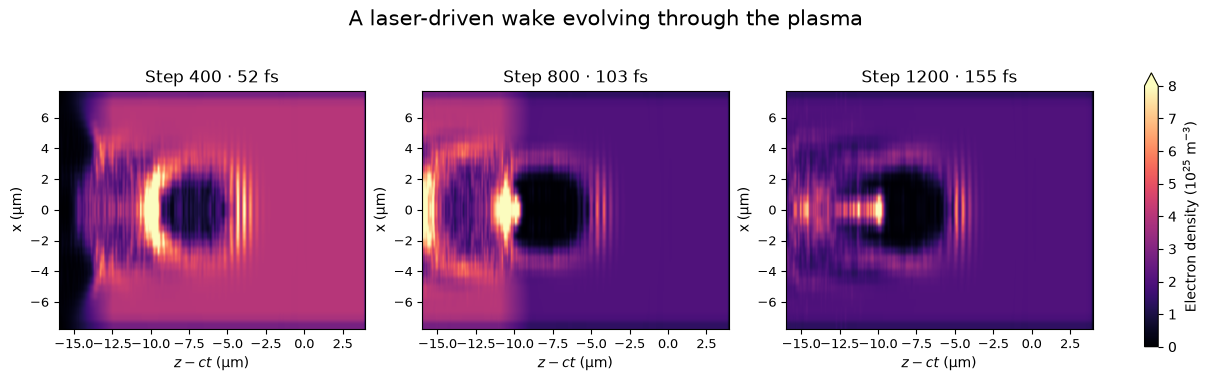

In [3]:
fig = plot_density_evolution(out_folder)
plt.show()

## Look at the wake

Change `iteration` to any saved step and rerun the cell. The middle frame
usually shows the wake inside the plasma; the final frame follows the beam
into vacuum. White contours indicate the laser field. The spectrum includes
all electrons still in the moving box, including untrapped plasma electrons.

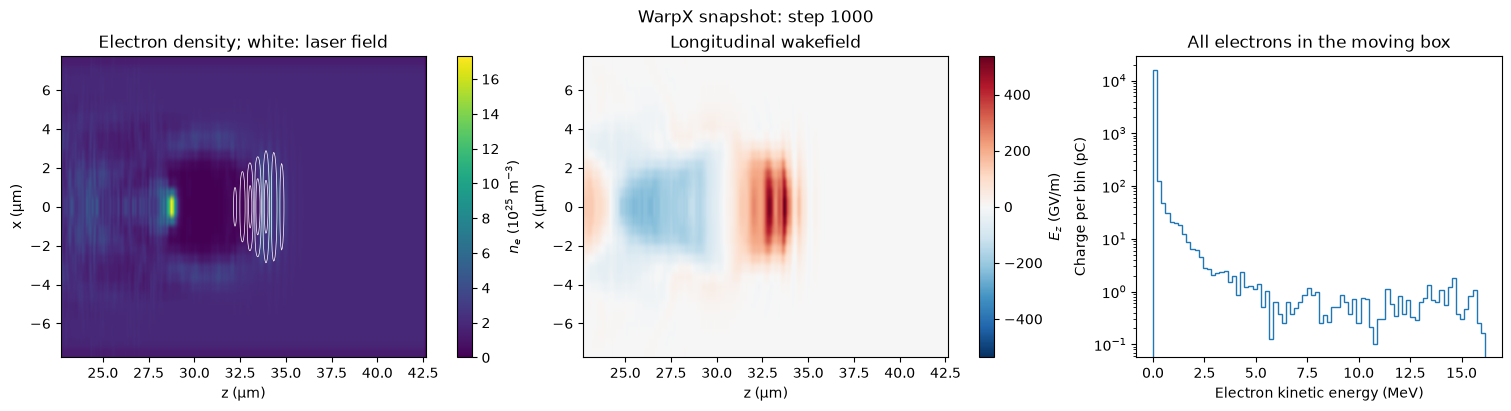

In [4]:
series = OpenPMDTimeSeries(out_folder)
iteration = int(series.iterations[len(series.iterations) // 2])
fig = plot_snapshot(out_folder, iteration)
plt.show()

## Connect output and computing cost

The default saves a snapshot every 200 steps and at the end. If time permits,
preserve the baseline output, change only `diag1.intervals` to `400` in the
input file, and rerun in the terminal. Compare elapsed time, disk use, and
available snapshots. The physical calculation still takes every time step;
only the saved history is less frequent. Select a step that exists in each
run when comparing plots.

For an optional physics variation, change only `a0`, the laser strength.
Rerun in the terminal and compare the wake and spectrum at the same saved
step. Changing a physical parameter is different from changing how often
we save the answer. A high-energy tail alone is not proof of a usable bunch.

Continue with the separate [ImpactX example](htu_transport.ipynb).
A WarpX-to-ImpactX transfer requires consistent particle selection, coordinates, and units; it is outside this tutorial.
